## Is Tajikistan a Hot Country?

For this assignment, I wanted to look at mean temperatures in countries. Then, I specifically chose Tajikistan, a country in Central Asia, because I will be studying abroad there this summer! I heard it may get slightly hotter than in the US, but let's use real data and see how warm the weather there can get.

#### City Temperature Dataset

I found a dataset on Kaggle.com called called [Daily Temperature of Major Cities](https://www.kaggle.com/datasets/sudalairajkumar/daily-temperature-of-major-cities). Here is what it looks like.

In [11]:
import pandas as pd

temp = pd.read_csv('city_temperature.csv')

temp.head()

C:\Users\sunmi\AppData\Local\Temp\ipykernel_28272\857493218.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv('city_temperature.csv')


,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


#### Cleaning and filtering for Tajikistan

In [12]:
tj = temp[temp['Country'] == 'Tajikistan']
tj = tj[tj['AvgTemperature'] != '-99']
tj = tj[tj['Year'] >= 2015]

tj = tj.drop('State', axis=1)

tj.head()

,Region,Country,City,Month,Day,Year,AvgTemperature
531874,Asia,Tajikistan,Dusanbe,1,1,2015,44.5
531875,Asia,Tajikistan,Dusanbe,1,2,2015,43.0
531876,Asia,Tajikistan,Dusanbe,1,3,2015,45.0
531877,Asia,Tajikistan,Dusanbe,1,4,2015,46.6
531878,Asia,Tajikistan,Dusanbe,1,5,2015,43.0


I will be staying in Dushanbe, the capital city of Tajikistan.

## Monthly Average Temperature in Tajikistan, 2015 to 2020

First, I wanted to take a look at overall temperature trends year-round in Dushanbe, Tajikistan. My first step here is to convert the data to a datetime column, group the data by month, and calculate the mean, standard deviation, and count. Then, I computed a 95% confidence interval to calculate the uncertainty around each monthly mean temperature.

In [13]:
tj["Date"] = pd.to_datetime(tj[["Year", "Month", "Day"]])

monthly = tj.groupby(tj["Date"].dt.to_period("M")).agg(
    mean_temp=("AvgTemperature", "mean"),
    std_temp=("AvgTemperature", "std"),
    count=("AvgTemperature", "count")
).reset_index()

monthly["Date"] = monthly["Date"].dt.to_timestamp()

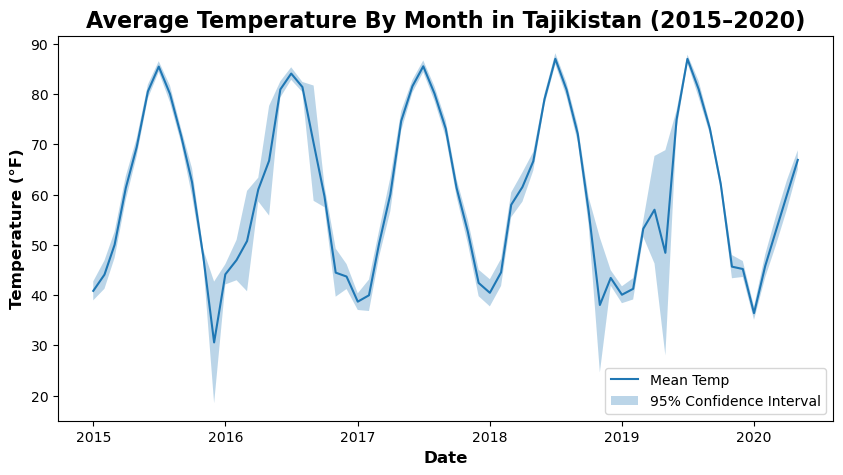

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 95% confidence interval
monthly["ci"] = 1.96 * (monthly["std_temp"] / np.sqrt(monthly["count"]))

plt.figure(figsize=(10,5))

# mean line
plt.plot(monthly["Date"], monthly["mean_temp"], label="Mean Temperature")

# confidence band
plt.fill_between(
    monthly["Date"],
    monthly["mean_temp"] - monthly["ci"],
    monthly["mean_temp"] + monthly["ci"],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Average Temperature By Month in Tajikistan (2015–2020)", fontweight='bold', fontsize=16)
plt.xlabel("Date", fontweight='bold', fontsize=12)
plt.ylabel("Temperature (°F)", fontweight='bold', fontsize=12)
plt.legend()
plt.show()

In this graph, the highest monthly average in the summer is around 85°F, and the lowest in the winter is around 36°F. The overall pattern of being cold in the winter and hot in the summer is very clear and has a repeating cycle. I believe we can assume the same for summer 2026 in Tajikistan, and I can expect an average of the temperature being approximately 85°F for most days during June and July.

## Mean Temperature In Tajikistan, Summer 2019

Since I will be studying in Tajikistan for the entirety of June and July, I wanted to make a bootstrap loop of 1000 random temperatures in Tajikistan over that time period.

In [29]:
temp = pd.read_csv('city_temperature.csv')
tj = temp[temp['Country'] == 'Tajikistan']
tj = tj[tj['Year'] == 2019]
tj = tj[tj['Month'] >= 6]
tj = tj[tj['Month'] <= 7]

C:\Users\sunmi\AppData\Local\Temp\ipykernel_28272\843846346.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv('city_temperature.csv')


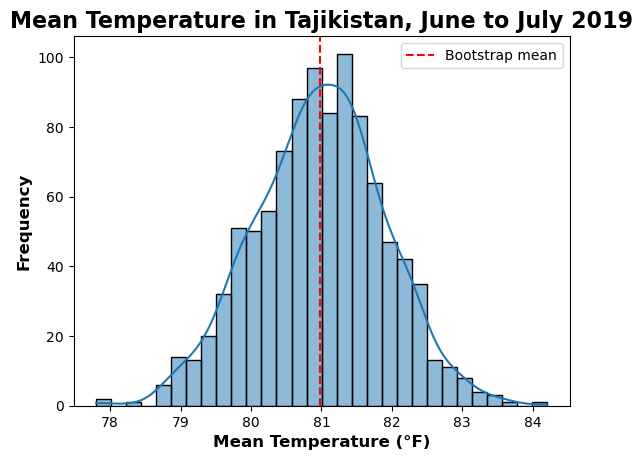

In [30]:
import seaborn as sns
from sklearn.utils import resample

means = []

for i in range(1000):
    sample = resample(tj["AvgTemperature"], random_state=i)
    means.append(sample.mean())

sns.histplot(means, kde=True, bins=30)

plt.axvline(np.mean(means), color='r', linestyle='--', label="Bootstrap mean")

plt.title("Mean Temperature in Tajikistan, June to July 2019", fontweight='bold', fontsize=16)
plt.xlabel("Mean Temperature (°F)", fontweight='bold', fontsize=12)
plt.ylabel("Frequency", fontweight='bold', fontsize=12)
plt.legend()
plt.show()

In this graph, the bootstrap mean is approximately 83°F. The histogram looks like a uniform distribution, with possibly a very slight left skew. The lowest value of the histogram is 81°F, and the highest is 85°F. Overall, each randomly selected temperature from each day ranges from ~78°F to ~84°F.

## Reflection

Uncertainty plays a role in how I interpret my results. For my first "Average Temperature By Month" graph, there were some obvious uncertainties such as during the winter of 2016 and the spring of 2019. Clearly, the averages may not be exact and also may not correlate to what the temperatures will be in the summer of 2026. However, the mean temperature shows up and down trend and for most of the year and the confidence interval looks to be relatively not too far off from the mean.

My second graph showing mean temperatures over the summer of 2019 reinforces this idea using a bootstrap distribution by showing that even the mean itself is not a fixed number. By repeatedly resampling the data, I can see a range of possible mean temperatures rather than a single value. The spread of this distribution reflects how sensitive the average is to the specific data points included. If the distribution is tight, it suggests the mean is stable. If it’s more spread out, it indicates greater uncertainty and less confidence in pinpointing an exact value.

Even though the general season pattern in Tajikistan is consistent, there isn't one single temperature that I can expect during my time studying abroad this summer. In conclusion, incorporating uncertainty into my analysis makes my results more realistic and credible.